In [1]:
import torch                         # 파이토치 기본 라이브러리 (텐서, GPU 연산, 자동미분 등)
import torch.nn as nn                # 신경망 레이어, 활성화 함수, 손실 함수 등을 담은 모듈
import torch.optim as optim          # 가중치 업데이트를 위한 최적화 알고리즘(Adam, SGD 등)
from torchvision import datasets, transforms   # 이미지 데이터셋과 전처리 도구
from torch.utils.data import DataLoader         # 데이터를 batch 단위로 꺼내주는 도구

# GPU가 사용 가능하면 cuda를, 아니면 cpu를 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 현재 어떤 장치를 쓰는지 출력
print(f"현재 사용 중인 디바이스: {device}")

# ---------------------------
# 하이퍼파라미터 설정
# ---------------------------

batch_size = 100        # 한 번에 학습할 이미지 개수 = 1배치 크기
learning_rate = 0.0002  # 가중치를 얼마나 빠르게 수정할지 결정하는 학습률
num_epochs = 50         # 전체 훈련 데이터를 몇 바퀴 반복할지
latent_size = 64        # 생성자 입력용 랜덤 노이즈 벡터 길이
hidden_size = 256       # 은닉층 뉴런 수
image_size = 28 * 28    # MNIST 이미지 1장의 총 픽셀 수 (28x28=784)

# ---------------------------
# 이미지 전처리
# ---------------------------

# Compose는 여러 전처리를 순서대로 묶어주는 역할
transform = transforms.Compose([
    transforms.ToTensor(),                 # 이미지를 텐서로 바꾸고, 픽셀값을 0~255 -> 0~1로 변환
    transforms.Normalize(mean=[0.5], std=[0.5])  # 0~1 범위를 대략 -1~1 범위로 정규화
])

# MNIST 훈련 데이터를 불러옴
# root='./data' : data 폴더에 저장
# train=True    : 훈련용 데이터 사용
# transform     : 이미지 꺼낼 때 위 전처리 자동 적용
# download=True : 없으면 인터넷에서 다운로드
mnist_data = datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

# DataLoader:
# 데이터를 batch_size 단위로 묶어서 꺼내줌
# shuffle=True : 매 epoch마다 데이터 순서를 섞음
data_loader = DataLoader(
    dataset=mnist_data,
    batch_size=batch_size,
    shuffle=True
)

# ---------------------------
# 판별자(Discriminator) 정의
# 역할: 입력 이미지가 진짜인지 가짜인지 판별
# 입력: [batch, 784]
# 출력: [batch, 1]  -> 각 이미지가 진짜일 확률 비슷한 값
# ---------------------------
class Discriminator(nn.Module):
    def __init__(self):
        # 부모 클래스(nn.Module) 초기화
        super(Discriminator, self).__init__()

        # Sequential:
        # 안에 있는 레이어를 순서대로 실행
        self.model = nn.Sequential(
            nn.Linear(image_size, hidden_size),  # 784 -> 256
            nn.LeakyReLU(0.2),                   # 음수도 조금 살려주는 활성화 함수
            nn.Linear(hidden_size, hidden_size), # 256 -> 256
            nn.LeakyReLU(0.2),                   # 다시 비선형성 추가
            nn.Linear(hidden_size, 1),           # 256 -> 1
            nn.Sigmoid()                         # 출력값을 0~1 사이로 압축
        )

    def forward(self, x):
        # x를 self.model에 통과시켜 결과 반환
        return self.model(x)

# ---------------------------
# 생성자(Generator) 정의
# 역할: 랜덤 노이즈를 받아 가짜 이미지를 생성
# 입력: [batch, 64]
# 출력: [batch, 784]
# ---------------------------
class Generator(nn.Module):
    def __init__(self):
        # 부모 클래스(nn.Module) 초기화
        super(Generator, self).__init__()

        # 생성자 신경망 구조
        self.model = nn.Sequential(
            nn.Linear(latent_size, hidden_size), # 64 -> 256
            nn.ReLU(),                           # 음수는 0, 양수는 그대로
            nn.Linear(hidden_size, hidden_size), # 256 -> 256
            nn.ReLU(),                           # 다시 비선형성 추가
            nn.Linear(hidden_size, image_size),  # 256 -> 784
            nn.Tanh()                            # 출력값을 -1~1 사이로 압축
        )

    def forward(self, x):
        # 노이즈 x를 받아 가짜 이미지 벡터 반환
        return self.model(x)

# ---------------------------
# 모델 생성 및 device로 이동
# ---------------------------

D = Discriminator().to(device)  # 판별자 모델 생성 후 GPU/CPU로 이동
G = Generator().to(device)      # 생성자 모델 생성 후 GPU/CPU로 이동

# BCELoss:
# Binary Cross Entropy Loss
# 진짜(1) / 가짜(0) 같은 이진 분류에서 예측과 정답 차이를 계산
criterion = nn.BCELoss()

# Adam 옵티마이저:
# backward()로 구한 gradient를 바탕으로 실제 가중치를 수정하는 역할
d_optimizer = optim.Adam(D.parameters(), lr=learning_rate)  # 판별자용 옵티마이저
g_optimizer = optim.Adam(G.parameters(), lr=learning_rate)  # 생성자용 옵티마이저

# 한 epoch당 총 batch 수
# 예: 60000개 데이터를 batch_size=100으로 나누면 약 600 step
total_step = len(data_loader)

# ---------------------------
# 학습 시작
# ---------------------------

for epoch in range(num_epochs):  # 전체 데이터를 num_epochs번 반복
    # data_loader에서 batch 단위로 데이터 꺼냄
    # images: 이미지 묶음
    # _     : 라벨인데 GAN에서는 사용 안 하므로 버림
    for i, (images, _) in enumerate(data_loader):

        # images의 원래 shape는 [batch_size, 1, 28, 28]
        # view(batch_size, -1)은 이미지를 1줄짜리 벡터로 펴서 [batch_size, 784]로 바꿈
        # 그리고 .to(device)로 GPU/CPU로 이동
        images = images.view(batch_size, -1).to(device)

        # 진짜 이미지의 정답 라벨 생성
        # shape: [batch_size, 1]
        # 값은 전부 1
        real_labels = torch.ones(batch_size, 1).to(device)

        # 가짜 이미지의 정답 라벨 생성
        # shape: [batch_size, 1]
        # 값은 전부 0
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # ---------------------------
        # 1. 판별자 학습 (진짜 이미지)
        # ---------------------------

        # 진짜 이미지를 판별자에 넣음
        # outputs shape: [batch_size, 1]
        outputs = D(images)

        # 진짜 이미지는 1이어야 하므로 real_labels와 비교해서 손실 계산
        d_loss_real = criterion(outputs, real_labels)

        # ---------------------------
        # 2. 가짜 이미지 생성
        # ---------------------------

        # 랜덤 노이즈 생성
        # shape: [batch_size, latent_size] = [100, 64]
        z = torch.randn(batch_size, latent_size).to(device)

        # 생성자에 노이즈를 넣어 가짜 이미지 생성
        # fake_images shape: [batch_size, 784]
        fake_images = G(z)

        # ---------------------------
        # 3. 판별자 학습 (가짜 이미지)
        # ---------------------------

        # detach():
        # fake_images를 계산 그래프에서 분리
        # 즉, 지금 판별자 학습 중이므로 생성자 쪽으로 gradient가 가지 않게 막음
        outputs = D(fake_images.detach())

        # 가짜 이미지는 0이어야 하므로 fake_labels와 비교해서 손실 계산
        d_loss_fake = criterion(outputs, fake_labels)

        # 진짜 손실 + 가짜 손실 = 판별자 전체 손실
        d_loss = d_loss_real + d_loss_fake

        # 판별자 gradient 초기화
        d_optimizer.zero_grad()

        # 판별자 손실 기준으로 역전파 -> gradient 계산
        d_loss.backward()

        # 계산된 gradient를 이용해 판별자 가중치 업데이트
        d_optimizer.step()

        # ---------------------------
        # 4. 생성자 학습
        # ---------------------------

        # 이번에는 detach 없이 fake_images를 판별자에 다시 넣음
        # 이유: 이번에는 생성자 쪽으로 gradient가 흘러가야 하기 때문
        outputs = D(fake_images)

        # 생성자의 목표:
        # 자기가 만든 가짜 이미지를 판별자가 "진짜(1)"라고 믿게 만들기
        # 그래서 정답을 fake_labels가 아니라 real_labels로 둠
        g_loss = criterion(outputs, real_labels)

        # 생성자 gradient 초기화
        g_optimizer.zero_grad()

        # 생성자 손실 기준으로 역전파 -> 생성자 gradient 계산
        g_loss.backward()

        # 생성자 가중치 업데이트
        g_optimizer.step()

        # ---------------------------
        # 중간 로그 출력
        # ---------------------------

        # 100 step마다 현재 손실 출력
        if (i + 1) % 100 == 0:
            print(
                f'Epoch [{epoch+1}/{num_epochs}], '
                f'Step [{i+1}/{total_step}], '
                f'D Loss: {d_loss.item():.4f}, '
                f'G Loss: {g_loss.item():.4f}'
            )

# 학습 종료 메시지
print("GAN 학습이 성공적으로 완료되었습니다!")

현재 사용 중인 디바이스: cuda
Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

Epoch [1/50], Step [100/600], D Loss: 0.4178, G Loss: 2.2746
Epoch [1/50], Step [200/600], D Loss: 0.0399, G Loss: 4.2778
Epoch [1/50], Step [300/600], D Loss: 0.4814, G Loss: 2.2143
Epoch [1/50], Step [400/600], D Loss: 0.0879, G Loss: 5.5105
Epoch [1/50], Step [500/600], D Loss: 0.0325, G Loss: 5.4863
Epoch [1/50], Step [600/600], D Loss: 0.0294, G Loss: 5.2625
Epoch [2/50], Step [100/600], D Loss: 0.0802, G Loss: 4.6536
Epoch [2/50], Step [200/600], D Loss: 0.0390, G Loss: 5.6816
Epoch [2/50], Step [300/600], D Loss: 0.0427, G Loss: 5.2597
Epoch [2/50], Step [400/600], D Loss: 0.2334, G Loss: 3.2309
Epoch [2/50], Step [500/600], D Loss: 0.3891, G Loss: 3.1306
Epoch [2/50], Step [600/600], D Loss: 0.1169, G Loss: 5.3202
Epoch [3/50], Step [100/600], D Loss: 0.1561, G Loss: 3.8671
Epoch [3/50], Step [200/600], D Loss: 0.3325, G Loss: 2.9379
Epoch [3/50], Step [300/600], D Loss: 0.1441, G Loss: 4.7563
Epoch [3/5

이미지 생성 시작 (디바이스: cuda)


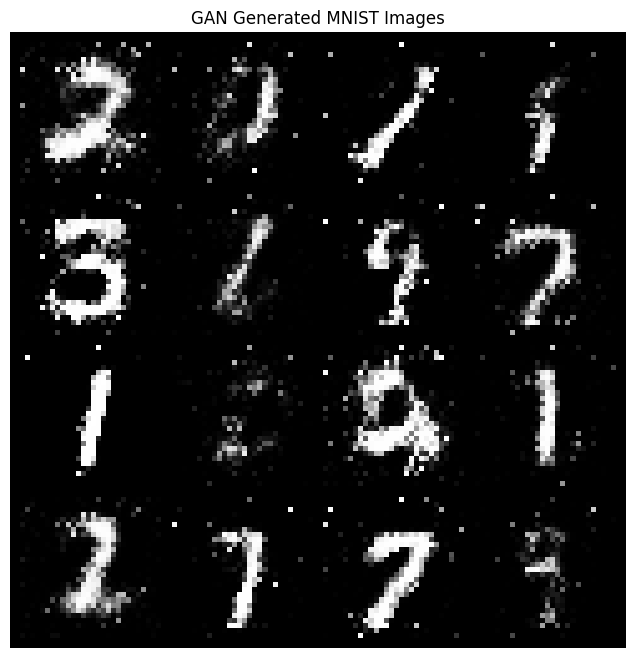

이미지 출력이 완료되었습니다.


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision.utils as vutils

print("이미지 생성 시작 (디바이스: cuda)")

G.eval()

num_generate = 16
latent_size = 64 

z = torch.randn(num_generate, latent_size).to(device)

with torch.no_grad():
    fake_images_1d = G(z)

fake_images_numpy = fake_images_1d.cpu().numpy()
fake_images_2d = fake_images_numpy.reshape(num_generate, 1, 28, 28)

fake_images_normalized = fake_images_2d * 0.5 + 0.5

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("GAN Generated MNIST Images")

final_images_tensor = torch.from_numpy(fake_images_normalized)
grid_img = vutils.make_grid(final_images_tensor, nrow=4, padding=2, normalize=False)

plt.imshow(np.transpose(grid_img.numpy(), (1, 2, 0)), cmap='gray')
plt.show()

print("이미지 출력이 완료되었습니다.")